In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/df_model_v2.csv")
print(df.shape)
df.head(3)
print(df.columns)

(16708, 31)
Index(['id', 'url', 'fecha_scraping', 'precio_clp', 'log_precio',
       'es_automotora', 'anio', 'edad_auto', 'kilometraje', 'marca', 'modelo',
       'region', 'comuna', 'combustible', 'transmision', 'tipo_carroceria',
       'cilindrada_cc', 'potencia_hp', 'traccion', 'puertas', 'tiene_garantia',
       'unico_dueno', 'al_dia', 'flag_impecable', 'score_match',
       'match_confirmado', 'n_versiones', 'llave_yapo', 'llave_sii_match',
       'llave_sii_match_final', 'score_match_final'],
      dtype='str')


Porcentaje de Nulos tras cruce con SII:
tipo_carroceria    0.0
cilindrada_cc      0.0
potencia_hp        0.0
traccion           0.0
puertas            0.0
dtype: float64


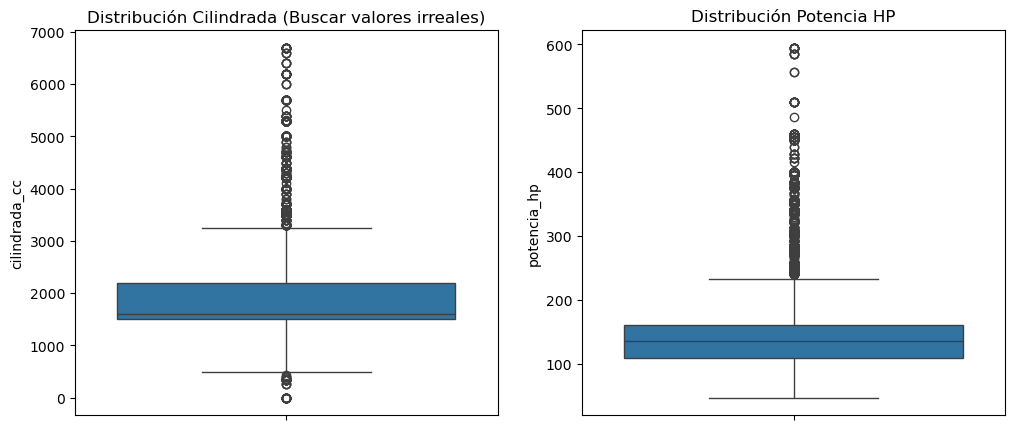

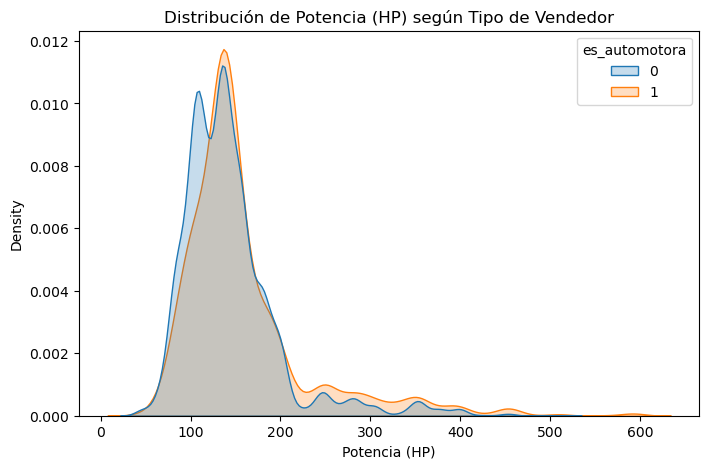

In [2]:


# Asumiendo que df es tu dataframe fusionado
# 1. Chequeo de Nulos
cols_sii = ['tipo_carroceria', 'cilindrada_cc', 'potencia_hp', 'traccion', 'puertas']
nulos_sii = df[cols_sii].isnull().mean() * 100
print("Porcentaje de Nulos tras cruce con SII:")
print(nulos_sii)

# 2. Convertir a numérico (en caso de que hayan quedado como strings tras el merge)
for col in ['cilindrada_cc', 'potencia_hp', 'puertas', 'log_precio', 'kilometraje']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Distribución para detectar Outliers (ej. Errores de tipeo en SII)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['cilindrada_cc'], ax=ax[0])
ax[0].set_title('Distribución Cilindrada (Buscar valores irreales)')
sns.boxplot(y=df['potencia_hp'], ax=ax[1])
ax[1].set_title('Distribución Potencia HP')
plt.show()

# 4. Impacto visual de las nuevas variables sobre el Tratamiento (D)
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='potencia_hp', hue='es_automotora', common_norm=False, fill=True)
plt.title('Distribución de Potencia (HP) según Tipo de Vendedor')
plt.xlabel('Potencia (HP)')
plt.show()